<a href="https://colab.research.google.com/github/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/blob/main/03_Machine_Learning_Essentil_for_Bioinformatics/01.%20Supervised_ML_TCGA_BRCA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile

with zipfile.ZipFile('data.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [3]:
import pandas as pd

df = pd.read_csv('data.csv')
print(df.head())

   rs_CLEC3A    rs_CPB1  rs_SCGB2A2  rs_SCGB1D2    rs_TFF1   rs_MUCL1  \
0   0.892818   6.580103   14.123672   10.606501  13.189237   6.649466   
1   0.000000   3.691311   17.116090   15.517231   9.867616   9.691667   
2   3.748150   4.375255    9.658123    5.326983  12.109539  11.644307   
3   0.000000  18.235519   18.535480   14.533584  14.078992   8.913760   
4   0.000000   4.583724   15.711865   12.804521   8.881669   8.430028   

    rs_GSTM1     rs_PIP  rs_ADIPOQ   rs_ADH1B  ...  pp_p27.pT198  pp_p38.MAPK  \
0  10.520335  10.338490  10.248379  10.229970  ...     -0.043330    -0.002598   
1   8.179522   7.911723   1.289598   1.818891  ...     -0.220764     0.220809   
2  10.517330   5.114925  11.975349  11.911437  ...      0.010615    -0.133214   
3  10.557465  13.304434   8.205059   9.211476  ...      0.064070    -0.384008   
4  12.964607   6.806517   4.294341   5.385714  ...     -0.065488     0.209858   

   pp_p38.pT180.Y182    pp_p53  pp_p62.LCK.ligand  pp_p70S6K  pp_p70S6K.pT

In [5]:
# Step 1: Data Preparation(Features & Target)

# Yahan hum 'vital.status' ko drop kar rahe hain kyunki ye hamara Target hai
# Baki sabhi columns hamare Features (X) ban jayenge
X = df.drop('vital.status', axis=1)

# Sirf 'vital.status' ko hum Target (y) mein le rahe hain
# Isse model sikhega ki hamein kya predict karna hai
y = df['vital.status']

# Check kar rahe hain ki data sahi se divide hua ya nahi
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (705, 1936)
Target (y) shape: (705,)


In [6]:
# Step 2: Dividing data into Training aur Testing sets

# Scikit-learn library se train_test_split import kar rahe hain
from sklearn.model_selection import train_test_split

# Data ko 80% training aur 20% testing mein divide kar rahe hain
# 'random_state=42' ka use karte hain taaki har baar same result mile
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check kar rahe hain ki split sahi se hua ya nahi
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (564, 1936)
Testing data shape: (141, 1936)


In [7]:
# Step 3: Model Training (Model ko sikhana)

# Random Forest Classifier ko import kar rahe hain
from sklearn.ensemble import RandomForestClassifier

# Model ko select kiya
model = RandomForestClassifier(random_state=42)

# Model ko training data (X_train aur y_train) se sikha rahe hain
model.fit(X_train, y_train)

print("Model training complete ho gaya hai!")


Model training complete ho gaya hai!


In [8]:
# Step 4: Model Evaluation (Model ki accuracy check karna)

# Pehle model se prediction karwayenge testing data par
y_pred = model.predict(X_test)

# Ab check karenge ki kitni predictions sahi hain
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print(f"Model ki accuracy hai: {accuracy * 100:.2f}%")

Model ki accuracy hai: 90.07%


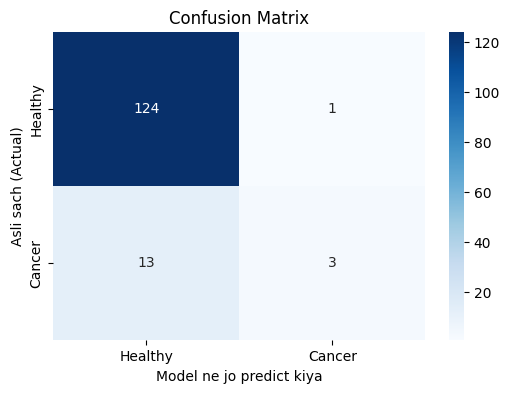

In [9]:
# Step 5: Confusion Matrix (Model ki galtiyon ko samajhna)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix banate hain
cm = confusion_matrix(y_test, y_pred)

# Graph (Heatmap) ke roop mein dikhate hain
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Cancer'],
            yticklabels=['Healthy', 'Cancer'])
plt.xlabel('Model ne jo predict kiya')
plt.ylabel('Asli sach (Actual)')
plt.title('Confusion Matrix')
plt.show()

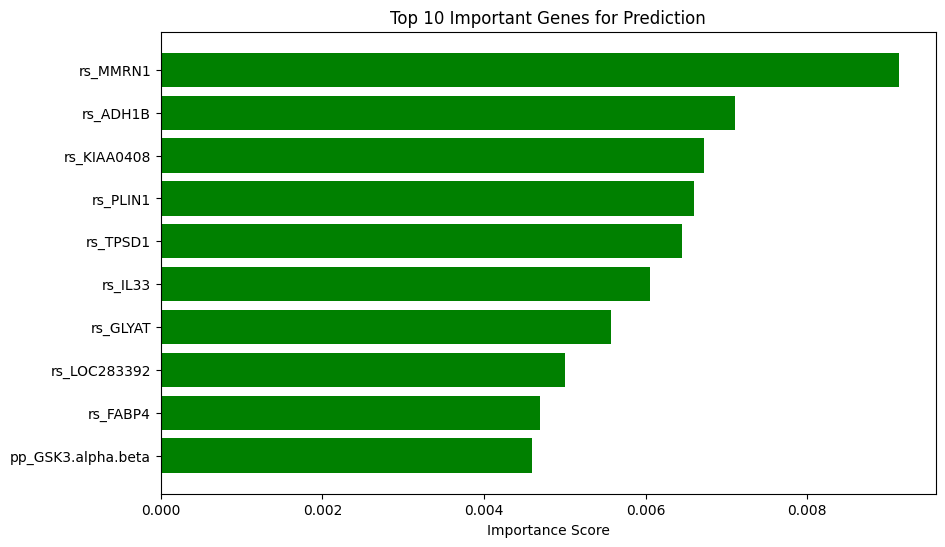

In [10]:
# Step 6: Feature Importance - Sabse zaroori Genes ki pehchan

import pandas as pd
import matplotlib.pyplot as plt

# Model se importance nikaal rahe hain
importances = model.feature_importances_

# Features ke naam aur unki importance ko combine kar rahe hain
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Importance ke hisaab se top 10 genes ko nikaal rahe hain
top_10_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Ab iska graph bana rahe hain
plt.figure(figsize=(10, 6))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='green')
plt.xlabel('Importance Score')
plt.title('Top 10 Important Genes for Prediction')
plt.gca().invert_yaxis() # Sabse important gene upar dikhega
plt.show()

In [11]:
# Step 7: Cross-Validation (Model ki mazbooti check karna)

from sklearn.model_selection import cross_val_score

# 5-Fold Cross-Validation: Model ko 5 baar alag-alag tukdon par test kar rahe hain
scores = cross_val_score(model, X, y, cv=5)

print(f"Sabhi 5 tests ke scores: {scores}")
print(f"Average Accuracy: {scores.mean() * 100:.2f}%")

Sabhi 5 tests ke scores: [0.87234043 0.85815603 0.92198582 0.87234043 0.85815603]
Average Accuracy: 87.66%


In [12]:
# Step 8: K-Fold Cross-Validation (Stable aur Reliable Result ke liye)

from sklearn.model_selection import KFold, cross_val_score

# Yahan humne KFold ka use kiya hai aur random_state=42 fix kar diya hai
# Shuffle=True ka matlab hai ki data ko har fold se pehle mix kiya jayega
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Ab hum is 'kf' (fixed settings) ka use karke score nikaal rahe hain
scores = cross_val_score(model, X, y, cv=kf)

print(f"Fixed random state (42) ke saath 5 tests ke scores: {scores}")
print(f"Final Average Accuracy: {scores.mean() * 100:.2f}%")

Fixed random state (42) ke saath 5 tests ke scores: [0.90070922 0.90070922 0.87234043 0.90780142 0.83687943]
Final Average Accuracy: 88.37%
